In [10]:
# Install once in Colab
!pip install easyocr opencv-python pandas openpyxl openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 15.1 MB/s eta 0:00:00


 **Module B: Advanced OCR & LLM Integration
"Traditional OCR (Tesseract/Google Vision) struggles with unstructured layouts or complex backgrounds. We want to use LLMs for extraction, but LLMs hallucinate. How do you ensure the 'Date of Birth' extracted is exactly what is on the pixel grid, with zero hallucination?"**


In [11]:
##Steps to be followed:
START
  ↓
Load Image(base64)
  ↓
LLM to extract the Image
  ↓
Validate the Extraction
  ↓
END

# 1. Load Image from Drive and Userdata

In [12]:
import os
import re
import json
import base64
from typing import TypedDict, Dict, Any, List, Optional
from google.colab import drive,userdata
import pandas as pd
from pathlib import Path
import glob
from openai import OpenAI
from langgraph.graph import StateGraph, START, END

drive.mount('/content/drive')

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))

REQUIRED_FIELDS = [
    "id_number",
    "full_name",
    "date_of_birth",
    "address",
    "nationality",
    "expiry_date"
]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
class KTPState(TypedDict, total=False):
    image_path: str
    image_base64: str
    llm_raw_output: Dict[str, Any]
    validated_fields: Dict[str, Any]
    final_result: Dict[str, Any]
    errors: List[str]

## Load the base64 image:

In [14]:
def load_image_node(state: KTPState) -> KTPState:
    image_path = state.get("image_path")

    if not image_path:
        return {
            **state,
            "errors": ["image_path missing"]
        }

    if not os.path.exists(image_path):
        return {
            **state,
            "errors": [f"Image not found: {image_path}"]
        }

    with open(image_path, "rb") as f:
        image_base64 = base64.b64encode(f.read()).decode("utf-8")

    return {
        **state,
        "image_base64": image_base64,
        "errors": []
    }

## Use LLM to extract the content:

In [15]:
def llm_extract_node(state: KTPState) -> KTPState:
    if state.get("errors"):
        return state

    if not state.get("image_base64"):
        return {
            **state,
            "errors": ["image_base64 missing. load_image_node failed."]
        }

    prompt = """
You are extracting fields from an Indonesian KTP card.

Return ONLY valid JSON.
Do not hallucinate.
If a value is not clearly visible, return null.

Extract ONLY:
- id_number
- full_name
- date_of_birth
- address
- nationality
- expiry_date

Rules:
1. id_number must come from NIK or any 16 digits number in the Id card.
2. full_name must come from Nama.
3. date_of_birth must come from Tempat/Tgl Lahir, it follow DD-MM-YYYY.
4. address must come from Alamat.
5. nationality must come from Kewarganegaraan.
6. expiry_date must come from Berlaku Hingga.
7. date_of_birth must be YYYY-MM-DD.
8. Do not include extra fields.

Return exactly:
{
  "id_number": null,
  "full_name": null,
  "date_of_birth": null,
  "address": null,
  "nationality": null,
  "expiry_date": null
}
"""

    response = client.responses.create(
        model="gpt-4.1",
        temperature=0,
        top_p=1,
        input=[
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": prompt},
                    {
                        "type": "input_image",
                        "image_url": f"data:image/jpeg;base64,{state['image_base64']}"
                    }
                ]
            }
        ],
        text={
            "format": {
                "type": "json_schema",
                "name": "ktp_extraction",
                "strict": True,
                "schema": {
                    "type": "object",
                    "properties": {
                        "id_number": {"type": ["string", "null"]},
                        "full_name": {"type": ["string", "null"]},
                        "date_of_birth": {"type": ["string", "null"]},
                        "address": {"type": ["string", "null"]},
                        "nationality": {"type": ["string", "null"]},
                        "expiry_date": {"type": ["string", "null"]}
                    },
                    "required": REQUIRED_FIELDS,
                    "additionalProperties": False
                }
            }
        }
    )

    return {
        **state,
        "llm_raw_output": json.loads(response.output_text)
    }

## Validate the Extracted Node to confirm that the LLM is not Hallucinate:

In [16]:
def validate_node(state: KTPState) -> KTPState:
    data = state["llm_raw_output"]
    errors = []

    validated = {
        field: data.get(field)
        for field in REQUIRED_FIELDS
    }

    # NIK validation
    if validated["id_number"]:
        nik = re.sub(r"\D", "", validated["id_number"])

        if len(nik) == 16:
            validated["id_number"] = nik
        else:
            errors.append("id_number rejected: NIK must contain exactly 16 digits")
            validated["id_number"] = None
    else:
        errors.append("id_number missing")

    # DOB validation
    dob = validated["date_of_birth"]

    if dob:
        if not re.fullmatch(r"\d{4}-\d{2}-\d{2}", dob):
            errors.append("date_of_birth rejected: must be YYYY-MM-DD")
            validated["date_of_birth"] = None
    else:
        errors.append("date_of_birth missing")

    # Nationality validation
    if validated["nationality"]:
        if validated["nationality"].upper() != "WNI":
            errors.append("nationality rejected: expected WNI")
            validated["nationality"] = None
        else:
            validated["nationality"] = "WNI"

    # Expiry validation
    if validated["expiry_date"]:
        if "SEUMUR" in validated["expiry_date"].upper() and "HIDUP" in validated["expiry_date"].upper():
            validated["expiry_date"] = "SEUMUR HIDUP"
    else:
        errors.append("expiry_date missing")

    return {
        **state,
        "validated_fields": validated,
        "errors": errors
    }

## After Validation

In [17]:
def final_node(state: KTPState) -> KTPState:
    return {
        **state,
        "final_result": {
            "success": len(state.get("errors", [])) == 0,
            "fields": state["validated_fields"],
            "reason_codes": state.get("errors", [])
        }
    }

## Workflow Orchestration:

In [18]:
workflow = StateGraph(KTPState)

workflow.add_node("load_image", load_image_node)
workflow.add_node("llm_extract", llm_extract_node)
workflow.add_node("validate", validate_node)
workflow.add_node("final", final_node)

workflow.add_edge(START, "load_image")
workflow.add_edge("load_image", "llm_extract")
workflow.add_edge("llm_extract", "validate")
workflow.add_edge("validate", "final")
workflow.add_edge("final", END)

ktp_graph = workflow.compile()

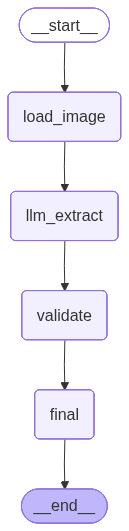

In [ ]:
ktp_graph

## Run for Single Example:

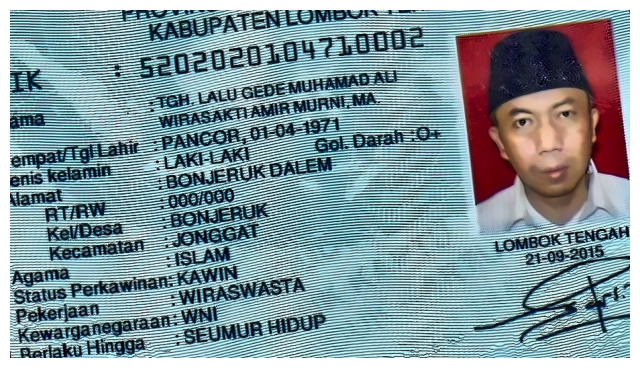

In [19]:
import matplotlib.pyplot as plt
import cv2

image_path = "/content/drive/My Drive/kyc_train/after_preprocess_image/clean/2e9496ad-ktp-23_jpg.rf.d664bbbe1ea41c58e6792a124caa9067.jpg"

# Read image
image = cv2.imread(image_path)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(8,6))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [20]:
image_path = "/content/drive/My Drive/kyc_train/after_preprocess_image/clean/2e9496ad-ktp-23_jpg.rf.d664bbbe1ea41c58e6792a124caa9067.jpg"

result = ktp_graph.invoke({
    "image_path": image_path
})

print(json.dumps(result["final_result"], indent=2, ensure_ascii=False))

{
  "success": true,
  "fields": {
    "id_number": "5202020104710002",
    "full_name": "TGH. LALU GEDE MUHAMAD ALI WIRASAKTI AMIR MURNI, MA.",
    "date_of_birth": "1971-04-01",
    "address": "BONJERUK DALEM 000/000",
    "nationality": "WNI",
    "expiry_date": "SEUMUR HIDUP"
  },
  "reason_codes": []
}


## Run for the images from the drive:

In [21]:
input_folder = "/content/drive/My Drive/kyc_train/after_preprocess_image/clean/"
output_folder = "/content/drive/My Drive/kyc_train/after_preprocess_image/LLM_Extracted_Data/"

os.makedirs(output_folder, exist_ok=True)

image_paths = (
    glob.glob(os.path.join(input_folder, "*.jpg")) +
    glob.glob(os.path.join(input_folder, "*.jpeg")) +
    glob.glob(os.path.join(input_folder, "*.png"))
)

print("Total images found:", len(image_paths))

results = []

for image_path in image_paths:
    try:
        result = ktp_graph.invoke({"image_path": image_path})

        final_result = result.get("final_result", {})
        fields = final_result.get("fields", {})

        row = {
            "image_path": image_path,
            "id_number": fields.get("id_number"),
            "full_name": fields.get("full_name"),
            "date_of_birth": fields.get("date_of_birth"),
            "address": fields.get("address"),
            "nationality": fields.get("nationality"),
            "expiry_date": fields.get("expiry_date"),
            "reason_codes": " | ".join(final_result.get("reason_codes", [])),
            "full_result_json": json.dumps(final_result, ensure_ascii=False)
        }

        print("Row:", row)
        results.append(row)

    except Exception as e:
        results.append({
            "image_path": image_path,
            "id_number": None,
            "full_name": None,
            "date_of_birth": None,
            "address": None,
            "nationality": None,
            "expiry_date": None,
            "reason_codes": str(e),
            "full_result_json": None
        })

Total images found: 201
Row: {'image_path': '/content/drive/My Drive/kyc_train/after_preprocess_image/clean/ab391159-ktp-16_jpg.rf.7f3da75ff655703144a959d241c2f881.jpg', 'id_number': '1112010402610002', 'full_name': 'DARMI', 'date_of_birth': '1961-02-04', 'address': 'DESA BARU', 'nationality': 'WNI', 'expiry_date': '04-02-2018', 'reason_codes': '', 'full_result_json': '{"success": true, "fields": {"id_number": "1112010402610002", "full_name": "DARMI", "date_of_birth": "1961-02-04", "address": "DESA BARU", "nationality": "WNI", "expiry_date": "04-02-2018"}, "reason_codes": []}'}
Row: {'image_path': '/content/drive/My Drive/kyc_train/after_preprocess_image/clean/14a928ad-ktp-29_jpg.rf.e74bad0309b246f3bb44c252cb3f15a5.jpg', 'id_number': '3574035008900003', 'full_name': 'RIZKI FIRMANANDA', 'date_of_birth': '1990-08-10', 'address': 'JL. SERMA ABD RAHMAN 002/004 WIROBORANG MAYANGAN', 'nationality': 'WNI', 'expiry_date': '10-08-2017', 'reason_codes': '', 'full_result_json': '{"success": true,

In [39]:
df = pd.DataFrame(results)

In [22]:
df = pd.DataFrame(results)

csv_path = os.path.join(output_folder, "ktp_extracted_results.csv")

df.to_csv(csv_path, index=False)

print("CSV saved:", csv_path)


CSV saved: /content/drive/My Drive/kyc_train/after_preprocess_image/LLM_Extracted_Data/ktp_extracted_results.csv


In [40]:
df.head(10)

,image_path,id_number,full_name,date_of_birth,address,nationality,expiry_date,reason_codes,full_result_json
0,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/ab391159-ktp-16_jpg.rf.7f3da75ff655703144a959d241c2f881.jpg,1112010402610002,DARMI,1961-02-04,DESA BARU,WNI,04-02-2018,,"{""success"": true, ""fields"": {""id_number"": ""1112010402610002"", ""full_name"": ""DARMI"", ""date_of_birth"": ""1961-02-04"", ""address"": ""DESA BARU"", ""nationality"": ""WNI"", ""expiry_date"": ""04-02-2018""}, ""reason_codes"": []}"
1,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/14a928ad-ktp-29_jpg.rf.e74bad0309b246f3bb44c252cb3f15a5.jpg,3574035008900003,RIZKI FIRMANANDA,1990-08-10,JL. SERMA ABD RAHMAN 002/004 WIROBORANG MAYANGAN,WNI,10-08-2017,,"{""success"": true, ""fields"": {""id_number"": ""3574035008900003"", ""full_name"": ""RIZKI FIRMANANDA"", ""date_of_birth"": ""1990-08-10"", ""address"": ""JL. SERMA ABD RAHMAN 002/004 WIROBORANG MAYANGAN"", ""nationality"": ""WNI"", ""expiry_date"": ""10-08-2017""}, ""reason_codes"": []}"
2,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/122abf84-ktp-69_jpg.rf.caa987f30eabcff2bd39f0651ee52ab0.jpg,None,MURNIATI AWALIA,2001-03-03,J1. H. SUPU YUSUF,WNI,None,id_number rejected: NIK must contain exactly 16 digits | expiry_date missing,"{""success"": false, ""fields"": {""id_number"": null, ""full_name"": ""MURNIATI AWALIA"", ""date_of_birth"": ""2001-03-03"", ""address"": ""J1. H. SUPU YUSUF"", ""nationality"": ""WNI"", ""expiry_date"": null}, ""reason_codes"": [""id_number rejected: NIK must contain exactly 16 digits"", ""expiry_date missing""]}"
3,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/7d2602fb-ktp-200_jpg.rf.6856d27f5864e6a907e9013143df0386.jpg,1116075073970003,MARTHA CYNTHIA DEWI,1997-03-17,JLN T UMAR NO: 86,WNI,SEUMUR HIDUP,,"{""success"": true, ""fields"": {""id_number"": ""1116075073970003"", ""full_name"": ""MARTHA CYNTHIA DEWI"", ""date_of_birth"": ""1997-03-17"", ""address"": ""JLN T UMAR NO: 86"", ""nationality"": ""WNI"", ""expiry_date"": ""SEUMUR HIDUP""}, ""reason_codes"": []}"
4,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/6a2ad321-IMG_20220519_165451_jpg.rf.a111486b9a69d6a3bf13ff0d566fcf9a.jpg,3210190704730003,HERI RAWAN,1973-04-07,DUSUN GIRIMUKTI RT 004/002,WNI,SEUMUR HIDUP,,"{""success"": true, ""fields"": {""id_number"": ""3210190704730003"", ""full_name"": ""HERI RAWAN"", ""date_of_birth"": ""1973-04-07"", ""address"": ""DUSUN GIRIMUKTI RT 004/002"", ""nationality"": ""WNI"", ""expiry_date"": ""SEUMUR HIDUP""}, ""reason_codes"": []}"
5,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/2f27f107-ktp-201_jpg.rf.c1afc7bcf082ce98357fd5fb80f911a8.jpg,3213282705900001,FAISAL FAHMI RAPSANUAN,1990-05-27,KP. CIAWI,WNI,27-05-2017,,"{""success"": true, ""fields"": {""id_number"": ""3213282705900001"", ""full_name"": ""FAISAL FAHMI RAPSANUAN"", ""date_of_birth"": ""1990-05-27"", ""address"": ""KP. CIAWI"", ""nationality"": ""WNI"", ""expiry_date"": ""27-05-2017""}, ""reason_codes"": []}"
6,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/70ed5783-ktp-46_jpg.rf.781a5defb7b36461631f71f75aaa3652.jpg,6403050402680001,RUSMAN,1968-02-04,JL. P. MANIMBORA,WNI,04-02-2017,,"{""success"": true, ""fields"": {""id_number"": ""6403050402680001"", ""full_name"": ""RUSMAN"", ""date_of_birth"": ""1968-02-04"", ""address"": ""JL. P. MANIMBORA"", ""nationality"": ""WNI"", ""expiry_date"": ""04-02-2017""}, ""reason_codes"": []}"
7,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/82bd1b36-ktp-27_jpg.rf.f70d5711b1a7d67e8a7f1b06474a3bd1.jpg,2105042604950002,DENI ARIANTO,1995-04-26,Jln. Batu Ampar,WNI,SEUMUR HIDUP,,"{""success"": true, ""fields"": {""id_number"": ""2105042604950002"", ""full_name"": ""DENI ARIANTO"", ""date_of_birth"": ""1995-04-26"", ""address"": ""Jln. Batu Ampar"", ""nationality"": ""WNI"", ""expiry_date"": ""SEUMUR HIDUP""}, ""reason_codes"": []}"
8,/content/drive/My Drive

##  LLM Extracting % of non null values of the DOB:

In [27]:
print((df['date_of_birth'].notna().sum()/df.shape[0]) *100)

93.53233830845771


## LLM Extracting % of non null values of the id_number:

In [28]:
print((df['id_number'].notna().sum()/df.shape[0]) *100)

90.04975124378109


## LLM Extracting % of non null values of the full_name:

In [29]:
print((df['full_name'].notna().sum()/df.shape[0]) *100)

91.54228855721394


In [30]:
pd.set_option('display.max_colwidth', None)

**Sample for Verification after LLM Extarction**

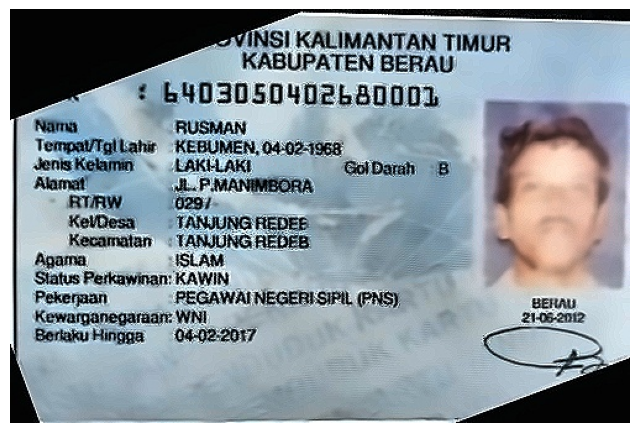

In [36]:
import matplotlib.pyplot as plt
import cv2

image_path = "/content/drive/My Drive/kyc_train/after_preprocess_image/clean/70ed5783-ktp-46_jpg.rf.781a5defb7b36461631f71f75aaa3652.jpg"

# Read image
image = cv2.imread(image_path)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(8,6))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [41]:
row = df.query("image_path == '/content/drive/My Drive/kyc_train/after_preprocess_image/clean/70ed5783-ktp-46_jpg.rf.781a5defb7b36461631f71f75aaa3652.jpg'")

In [42]:
row

,image_path,id_number,full_name,date_of_birth,address,nationality,expiry_date,reason_codes,full_result_json
6,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/70ed5783-ktp-46_jpg.rf.781a5defb7b36461631f71f75aaa3652.jpg,6403050402680001,RUSMAN,1968-02-04,JL. P. MANIMBORA,WNI,04-02-2017,,"{""success"": true, ""fields"": {""id_number"": ""6403050402680001"", ""full_name"": ""RUSMAN"", ""date_of_birth"": ""1968-02-04"", ""address"": ""JL. P. MANIMBORA"", ""nationality"": ""WNI"", ""expiry_date"": ""04-02-2017""}, ""reason_codes"": []}"


**PII Data Hashing Mechanism:**

In [45]:
df_2 =df.copy(deep=True)

In [46]:
df_2.head(5)

,image_path,id_number,full_name,date_of_birth,address,nationality,expiry_date,reason_codes,full_result_json
0,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/ab391159-ktp-16_jpg.rf.7f3da75ff655703144a959d241c2f881.jpg,1112010402610002,DARMI,1961-02-04,DESA BARU,WNI,04-02-2018,,"{""success"": true, ""fields"": {""id_number"": ""1112010402610002"", ""full_name"": ""DARMI"", ""date_of_birth"": ""1961-02-04"", ""address"": ""DESA BARU"", ""nationality"": ""WNI"", ""expiry_date"": ""04-02-2018""}, ""reason_codes"": []}"
1,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/14a928ad-ktp-29_jpg.rf.e74bad0309b246f3bb44c252cb3f15a5.jpg,3574035008900003,RIZKI FIRMANANDA,1990-08-10,JL. SERMA ABD RAHMAN 002/004 WIROBORANG MAYANGAN,WNI,10-08-2017,,"{""success"": true, ""fields"": {""id_number"": ""3574035008900003"", ""full_name"": ""RIZKI FIRMANANDA"", ""date_of_birth"": ""1990-08-10"", ""address"": ""JL. SERMA ABD RAHMAN 002/004 WIROBORANG MAYANGAN"", ""nationality"": ""WNI"", ""expiry_date"": ""10-08-2017""}, ""reason_codes"": []}"
2,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/122abf84-ktp-69_jpg.rf.caa987f30eabcff2bd39f0651ee52ab0.jpg,None,MURNIATI AWALIA,2001-03-03,J1. H. SUPU YUSUF,WNI,None,id_number rejected: NIK must contain exactly 16 digits | expiry_date missing,"{""success"": false, ""fields"": {""id_number"": null, ""full_name"": ""MURNIATI AWALIA"", ""date_of_birth"": ""2001-03-03"", ""address"": ""J1. H. SUPU YUSUF"", ""nationality"": ""WNI"", ""expiry_date"": null}, ""reason_codes"": [""id_number rejected: NIK must contain exactly 16 digits"", ""expiry_date missing""]}"
3,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/7d2602fb-ktp-200_jpg.rf.6856d27f5864e6a907e9013143df0386.jpg,1116075073970003,MARTHA CYNTHIA DEWI,1997-03-17,JLN T UMAR NO: 86,WNI,SEUMUR HIDUP,,"{""success"": true, ""fields"": {""id_number"": ""1116075073970003"", ""full_name"": ""MARTHA CYNTHIA DEWI"", ""date_of_birth"": ""1997-03-17"", ""address"": ""JLN T UMAR NO: 86"", ""nationality"": ""WNI"", ""expiry_date"": ""SEUMUR HIDUP""}, ""reason_codes"": []}"
4,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/6a2ad321-IMG_20220519_165451_jpg.rf.a111486b9a69d6a3bf13ff0d566fcf9a.jpg,3210190704730003,HERI RAWAN,1973-04-07,DUSUN GIRIMUKTI RT 004/002,WNI,SEUMUR HIDUP,,"{""success"": true, ""fields"": {""id_number"": ""3210190704730003"", ""full_name"": ""HERI RAWAN"", ""date_of_birth"": ""1973-04-07"", ""address"": ""DUSUN GIRIMUKTI RT 004/002"", ""nationality"": ""WNI"", ""expiry_date"": ""SEUMUR HIDUP""}, ""reason_codes"": []}"


In [47]:
import hashlib

salt = "my_secret_salt"

SHA256 Hash: 44582aac52ce4891ab2182893535823c52f68aa674bcef8f9a405e6c7aaa64de
16-digit Hashed ID: 3091305076454047


In [50]:
df_2['id_number'] = df_2['id_number'].apply(lambda x: hashlib.sha256((salt + x).encode()).hexdigest() if x is not None else '')

In [54]:
df_2.rename(columns={"id_number": "salted_hashed_id_number"}, inplace=True)

In [55]:
df_2.head(5)

,image_path,salted_hashed_id_number,full_name,date_of_birth,address,nationality,expiry_date,reason_codes,full_result_json
0,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/ab391159-ktp-16_jpg.rf.7f3da75ff655703144a959d241c2f881.jpg,4ab1cd50951f3e99ccecd61bf3f3b189e942a1ce00d63ecd93fc977f6c6a9f02,DARMI,1961-02-04,DESA BARU,WNI,04-02-2018,,"{""success"": true, ""fields"": {""id_number"": ""1112010402610002"", ""full_name"": ""DARMI"", ""date_of_birth"": ""1961-02-04"", ""address"": ""DESA BARU"", ""nationality"": ""WNI"", ""expiry_date"": ""04-02-2018""}, ""reason_codes"": []}"
1,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/14a928ad-ktp-29_jpg.rf.e74bad0309b246f3bb44c252cb3f15a5.jpg,44582aac52ce4891ab2182893535823c52f68aa674bcef8f9a405e6c7aaa64de,RIZKI FIRMANANDA,1990-08-10,JL. SERMA ABD RAHMAN 002/004 WIROBORANG MAYANGAN,WNI,10-08-2017,,"{""success"": true, ""fields"": {""id_number"": ""3574035008900003"", ""full_name"": ""RIZKI FIRMANANDA"", ""date_of_birth"": ""1990-08-10"", ""address"": ""JL. SERMA ABD RAHMAN 002/004 WIROBORANG MAYANGAN"", ""nationality"": ""WNI"", ""expiry_date"": ""10-08-2017""}, ""reason_codes"": []}"
2,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/122abf84-ktp-69_jpg.rf.caa987f30eabcff2bd39f0651ee52ab0.jpg,,MURNIATI AWALIA,2001-03-03,J1. H. SUPU YUSUF,WNI,None,id_number rejected: NIK must contain exactly 16 digits | expiry_date missing,"{""success"": false, ""fields"": {""id_number"": null, ""full_name"": ""MURNIATI AWALIA"", ""date_of_birth"": ""2001-03-03"", ""address"": ""J1. H. SUPU YUSUF"", ""nationality"": ""WNI"", ""expiry_date"": null}, ""reason_codes"": [""id_number rejected: NIK must contain exactly 16 digits"", ""expiry_date missing""]}"
3,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/7d2602fb-ktp-200_jpg.rf.6856d27f5864e6a907e9013143df0386.jpg,39cc618f07615c54c8ee5a49568c66d3df9db5ad909e6c56140c402319cd6309,MARTHA CYNTHIA DEWI,1997-03-17,JLN T UMAR NO: 86,WNI,SEUMUR HIDUP,,"{""success"": true, ""fields"": {""id_number"": ""1116075073970003"", ""full_name"": ""MARTHA CYNTHIA DEWI"", ""date_of_birth"": ""1997-03-17"", ""address"": ""JLN T UMAR NO: 86"", ""nationality"": ""WNI"", ""expiry_date"": ""SEUMUR HIDUP""}, ""reason_codes"": []}"
4,/content/drive/My Drive/kyc_train/after_preprocess_image/clean/6a2ad321-IMG_20220519_165451_jpg.rf.a111486b9a69d6a3bf13ff0d566fcf9a.jpg,7446ba3b704da112209abffb980282793b332eea5d11406db28fdfff9be825da,HERI RAWAN,1973-04-07,DUSUN GIRIMUKTI RT 004/002,WNI,SEUMUR HIDUP,,"{""success"": true, ""fields"": {""id_number"": ""3210190704730003"", ""full_name"": ""HERI RAWAN"", ""date_of_birth"": ""1973-04-07"", ""address"": ""DUSUN GIRIMUKTI RT 004/002"", ""nationality"": ""WNI"", ""expiry_date"": ""SEUMUR HIDUP""}, ""reason_codes"": []}"


**Reconstruct the PII Information**

In [56]:
hashed_output_folder = "/content/drive/My Drive/kyc_train/after_preprocess_image/Hashed_Id_Number/"

csv_path = os.path.join(hashed_output_folder, "ktp_extracted_hashed_numbers.csv")

df_2.to_csv(csv_path, index=False)

print("CSV saved:", csv_path)

CSV saved: /content/drive/My Drive/kyc_train/after_preprocess_image/Hashed_Id_Number/ktp_extracted_hashed_numbers.csv


In [58]:
import hashlib

salt = "my_secret_salt"

df_2["reverse_salted_hash"] = df_2["salted_hashed_id_number"].apply(
    lambda x: (
        str(
            int(
                hashlib.sha256((salt + str(x)).encode()).hexdigest(),
                16
            ) % 10**16
        ).zfill(16)
        if pd.notna(x)
        else ""
    )
)

In [65]:
df_2[["salted_hashed_id_number", "reverse_salted_hash","full_name"]].head(10)

,salted_hashed_id_number,reverse_salted_hash,full_name
0,4ab1cd50951f3e99ccecd61bf3f3b189e942a1ce00d63ecd93fc977f6c6a9f02,0230789180390793,DARMI
1,44582aac52ce4891ab2182893535823c52f68aa674bcef8f9a405e6c7aaa64de,1904806976404109,RIZKI FIRMANANDA
2,,7209690014090565,MURNIATI AWALIA
3,39cc618f07615c54c8ee5a49568c66d3df9db5ad909e6c56140c402319cd6309,9770477313897774,MARTHA CYNTHIA DEWI
4,7446ba3b704da112209abffb980282793b332eea5d11406db28fdfff9be825da,1542953092453589,HERI RAWAN
5,e22c38b5571f8e5954afa9a5a7cf99b11244c3d366ac25e1ccc078150db16cbd,8868025931102676,FAISAL FAHMI RAPSANUAN
6,01150e96a66ca89486faa9367b528df2bebd707efeb3f135fe9b44473e37b7f3,2190414828464387,RUSMAN
7,241a8c5bec903ceb6810eb63895190e583e9e761349b2f2993e1836b1ca6a211,0382531500728811,DENI ARIANTO
8,589b03f659ca6f801960c5e472071343dbc5ff2c263286752a7e22b7e6c253a8,9560409600502997,GUOHUI CHEN
9,14061e6f166fd1168b322593f6849d412a8474a07feaad57bb78c5f7eca4c868,6475636320794868,SAHRI SOLID
